### This code trains the WaveNet (fully ML) model with no transfer lear (in domain). For Sections 3.3 and 3.4 in the paper.

In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import copy
from matplotlib import colors
from sklearn import tree
#import skfda
#from sklearn import LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import seaborn as sns
from scipy import stats
from scipy.stats import truncnorm
import scipy.signal
#import cartopy.crs as ccrs
#import cartopy.io.shapereader as shpreader

import torch
import torch.nn as nn
import torch.optim as optim
#import torchvision
#import torch.nn.functional as F
#from torch.utils.data import TensorDataset, DataLoader, random_split
#import torchinfo

import warnings
import os
from copy import deepcopy
import sys
sys.path.append("C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\optimisation_experiments")
sys.path.append("C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\modelling_crop_phenology_in_data_scarce_regions_using_transfer_learning_code\\ML")
import plotting
import dataset_fctns
import modelling_fctns
from ML_fctns import *

from optimise_GDD_fctns import *
from WaveNet_fctns import *

from datetime import datetime
from dateutil.relativedelta import relativedelta
#from suntimes import SunTimes  

C:\Users\wlwc1989\Documents\Phenology_Test_Notebooks\phenology_dwd\optimisation_experiments\optimise_GDD_fctns.py:35: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  station_data = pd.read_csv("https://opendata.dwd.de/climate_environment/CDC/help/PH_Beschreibung_Phaenologie_Stationen_Jahresmelder.txt",sep = ";\s+|;\t+|;\s+\t+|;\t+\s+|;|\s+;|\t+;|\s+\t+;|\t+\s+;", encoding='cp1252', on_bad_lines='skip')


ModuleNotFoundError: No module named 'timeshap'

### First read in data

In [ ]:
skip = 1
numsteps = int(163 // skip)
#ds_inputs_DE1 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5_2001_2024_full.csv')
#ds_inputs_DE1[[f't2max at day {skip*n}' for n in range(numsteps)]] += -273.15
#ds_inputs_DE1[[f't2min at day {skip*n}' for n in range(numsteps)]] += -273.15
#ds_inputs_DE2 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5_90s.csv')

#ds_inputs_DE = pd.concat([ds_inputs_DE1, ds_inputs_DE2], axis = 0)
#ds_inputs_DE.loc[:, [f'temperature at day {n}' for n in range(200)]] = modelling_fctns.Wang_Engel_Temp_response(ds_inputs_DE.loc[:, [f'temperature at day {n}' for n in range(200)]], 7, 28, 42)
ds_inputs_DE = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5_full.csv')
ds_inputs_DE=ds_inputs_DE.rename(columns={'Referenzjahr':'year'})
print(len(ds_inputs_DE))
ds_inputs_DE = ds_inputs_DE.dropna(how='all')
print(len(ds_inputs_DE))
ds_inputs_DE = ds_inputs_DE.loc[ds_inputs_DE['observed time to beginning of flowering'] < 140]
ds_inputs_DE = ds_inputs_DE.loc[ds_inputs_DE['observed time to beginning of flowering'] > 40]
new_series = []
ds_inputs_DE.loc[:, [f't2max at day {skip*n}' for n in range(numsteps)]] = ds_inputs_DE.loc[:, [f't2max at day {skip*n}' for n in range(numsteps)]].values - ds_inputs_DE.loc[:, [f't2m at day {skip*n}' for n in range(numsteps)]].values
ds_inputs_DE.loc[:, [f't2min at day {skip*n}' for n in range(numsteps)]] = ds_inputs_DE.loc[:, [f't2m at day {skip*n}' for n in range(numsteps)]].values - ds_inputs_DE.loc[:, [f't2min at day {skip*n}' for n in range(numsteps)]].values
for variable_name in ['t2m', 't2max', 't2min', 'photoperiod', 'vpd']: #, 'ssrd', 'tp'
    data = ds_inputs_DE[[f'{variable_name} at day {skip*n}' for n in range(numsteps)]].values
    #if variable_name != 't2m' and variable_name != 'photoperiod':
    #    scaler = StandardScaler()
    #    scaler.fit(data)
    #    data = scaler.transform(data)
    new_variable_series = torch.Tensor(data)
    new_series.append(new_variable_series)

day_series_DE = torch.Tensor([[(skip*n)/10 for n in range(numsteps)] for count in range(len(ds_inputs_DE))])
year_series_DE = torch.Tensor([ds_inputs_DE['year'].values for count in range(numsteps)]).T
id_series_DE = torch.Tensor([ds_inputs_DE['Stations_id'].values for count in range(numsteps)]).T
temp_NDVI_series_DE = torch.swapaxes(torch.stack((*new_series, day_series_DE, year_series_DE, id_series_DE)), 0, 1)
ds_inputs_DE.loc[:, [f'DTF at day {n}' for n in range(193)]] = np.tile(ds_inputs_DE['observed time to beginning of flowering'].values, (193, 1)).T - np.tile(np.arange(0, 193), (len(ds_inputs_DE),1))
NDVI_labels_DE = torch.Tensor(ds_inputs_DE[[f'dev stage at day {skip*n}' for n in range(numsteps)]].astype('int64').values) #torch.Tensor(ds_inputs_DE['observed time to beginning of flowering'].astype('int64').values)

#NDVI_labels_DE = torch.Tensor(ds_inputs_DE['observed time to beginning of flowering'].astype(int).values).unsqueeze(1)
#NDVI_labels_DE = 100 - torch.Tensor(ds_inputs_DE[[f'DTF at day {skip*n}' for n in range(numsteps)]].astype('int64').values) #torch.Tensor(ds_inputs_DE['observed time to beginning of flowering'].astype('int64').values)
#NDVI_labels_DE = torch.Tensor(ds_inputs_DE[[f'DTF at day {skip*n}' for n in range(numsteps)]].astype('int64').values)

27153
27153


C:\Users\wlwc1989\AppData\Local\Temp\ipykernel_18592\1009952979.py:30: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\b\abs_34s6o8i12c\croot\libtorch_1751464457133\work\torch\csrc\utils\tensor_new.cpp:257.)
  year_series_DE = torch.Tensor([ds_inputs_DE['year'].values for count in range(numsteps)]).T


In [3]:
ds_inputs_SSA = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\SSA_ML_ERA5_1999_2008_with_varieties_fixed_vpd.csv')
ds_inputs_SSA = ds_inputs_SSA.loc[ds_inputs_SSA['observed time to beginning of flowering'] < 105]

In [4]:
ds_inputs_SSA = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\SSA_ML_ERA5_1999_2008.csv')
#ds_inputs_SSA.loc[:, [f'temperature at day {n}' for n in range(200)]] = modelling_fctns.Wang_Engel_Temp_response(ds_inputs_SSA.loc[:, [f'temperature at day {n}' for n in range(200)]], 7, 28, 42)
ds_inputs_SSA=ds_inputs_SSA.rename(columns={'Referenzjahr':'year'})
print(len(ds_inputs_SSA))
ds_inputs_SSA = ds_inputs_SSA.dropna(how='all')
print(len(ds_inputs_SSA))
ds_inputs_SSA = ds_inputs_SSA.loc[ds_inputs_SSA['observed time to beginning of flowering'] < 105]
skip = 1
numsteps = int(163 // skip)
new_series = []
ds_inputs_SSA.loc[:, [f't2max at day {skip*n}' for n in range(numsteps)]] = ds_inputs_SSA.loc[:, [f't2max at day {skip*n}' for n in range(numsteps)]].values - ds_inputs_SSA.loc[:, [f't2m at day {skip*n}' for n in range(numsteps)]].values
ds_inputs_SSA.loc[:, [f't2min at day {skip*n}' for n in range(numsteps)]] = ds_inputs_SSA.loc[:, [f't2m at day {skip*n}' for n in range(numsteps)]].values - ds_inputs_SSA.loc[:, [f't2min at day {skip*n}' for n in range(numsteps)]].values
for variable_name in ['t2m', 't2max', 't2min', 'photoperiod', 'vpd']:#['t2m', 'photoperiod', 'vpd']: #, 'ssrd', 'tp', 't2max', 't2min'
    data = ds_inputs_SSA[[f'{variable_name} at day {skip*n}' for n in range(numsteps)]].values
    if variable_name != 't2m' and variable_name != 'photoperiod':
        scaler = StandardScaler()
        scaler.fit(data)
        data = scaler.transform(data)
    new_variable_series = torch.Tensor(data)
    new_series.append(new_variable_series)

day_series_SSA = torch.Tensor([[(skip*n)/10 for n in range(numsteps)] for count in range(len(ds_inputs_SSA))])
year_series_SSA = torch.Tensor([ds_inputs_SSA['year'] for count in range(numsteps)]).T
id_series_SSA = torch.Tensor([ds_inputs_SSA['Stations_id'] for count in range(numsteps)]).T
temp_NDVI_series_SSA = torch.swapaxes(torch.stack((*new_series, day_series_SSA, year_series_SSA, id_series_SSA)), 0, 1)
ds_inputs_SSA.loc[:, [f'DTF at day {n}' for n in range(193)]] = np.tile(ds_inputs_SSA['observed time to beginning of flowering'].values, (193, 1)).T - np.tile(np.arange(0, 193), (len(ds_inputs_SSA),1))
NDVI_labels_SSA = torch.Tensor(ds_inputs_SSA[[f'dev stage at day {skip*n}' for n in range(numsteps)]].astype('int64').values) #torch.Tensor(ds_inputs_SSA['observed time to beginning of flowering'].astype('int64').values)
#NDVI_labels_SSA = torch.Tensor(ds_inputs_SSA[[f'DTF at day {skip*n}' for n in range(numsteps)]].astype('int64').values) #torch.Tensor(ds_inputs_SSA['observed time to beginning of flowering'].astype('int64').values)
#NDVI_labels_SSA = torch.Tensor(ds_inputs_SSA[[f'DTF at day {0}' for n in range(numsteps)]].astype('int64').values)

254
254


### Section 3.3: Cross-validation of WaveNet model in domain for data rich region.

In [53]:
bs = 256
n_channels = 5
#temp_NDVI_series_DE = torch.swapaxes(torch.stack((temp_series_DE, photoperiod_series_DE)), 0, 1)#, NDVI_series_DE
#temp_NDVI_series_DE = torch.swapaxes(temp_NDVI_series_DE, 2, 1)
#train_dl, val_dl = train_test_dl_from_tensors(temp_NDVI_series_DE, NDVI_labels_DE, bs = bs, n_channels = n_channels, train_proportion=0.8)
train_dl, val_dl = train_test_dl_by_year(temp_NDVI_series_DE, NDVI_labels_DE, test_years = [2022, 2023, 2024], year_column = -2, bs = bs, n_channels = 8, train_proportion=0.8)
#train_dl, val_dl = augment_tensor(features, labels, max_shift = 50, noise_magnitude = 0.1, scale_magnitude = 0.5, num_augs = 12)

input_dim = n_channels # Example: 100-dimensional word embeddings
hidden_dim = 4 #8 for SSA, 32 for DE
num_layers = 3 #2 for SSA
output_dim = 1  # Example: 5 classes
save_name = 'testerr'
bce = True
CNN = True
MMD = False
regression=False#True
KG=True
KG_vpd = False
normalise_at_end = False#True
model_args = (input_dim, hidden_dim, num_layers, output_dim, KG, MMD, None, regression, KG_vpd, normalise_at_end, 8, 22, 39)

#criterion = weighted_MSELoss(weights = MSE_weights) #nn.NLLLoss()  # For multi-class classification
criterion = nn.BCELoss()
#criterion = survival_loss()
criterion = problist_square_loss()
#criterion = nn.MSELoss()
MMD_loss = MMDLoss(weight=0.01)
#optimizer = torch.optim.Adam(model.parameters(), lr=0.001)#, weight_decay = 0.001)
#optimizer = torch.optim.SGD(model.parameters(), lr=0.5)
lr = 0.0001
epochs = 50
GDD_init = [[0.33255554, 7.01088182, 23.30372493, 39.15531463],
            [0.5211015 , 7.97262452, 26.93599014, 39.03618276],
            [0.32364492, 7.77869448, 23.14973298, 39.31765333],
            [0.36357164, 7.39815342, 24.93931749, 39.26584633],
            [0.3354603 , 7.12958798, 24.48095047, 39.61850868],
            [0.32169801, 7.0014374 , 23.95026893, 39.29402994]]
year_folds = [list(range(1991 + 6*n, 1991 + 6*n + 6)) for n in range(5)] + [[2021, 2022, 2023, 2024]]
loss_values, R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs = K_fold_crossval(5, (temp_NDVI_series_DE, NDVI_labels_DE), Causal_CNN_Classifier_KG, 
                                                                                                        epochs, bs, model_args, 
                                                                                                        lr = lr, 
                                                                                                        loss = 'MSE', CNN=CNN, bce=bce, 
                                                                                                        custom_loss=problist_square_loss, DTF = False, 
                                                                                                        year_split = True, year_folds = year_folds,
                                                                                                        GDD_init=GDD_init, verbose=True)

Fold 1
19715 7428
[0.33255554, 7.01088182, 23.30372493, 39.15531463]
0 39.49118683070299 44.233305931348085
5 39.01566931037409 42.415072583869765
10 38.561866313964316 41.28721457292909
15 37.6945191596445 42.053910524278926
20 36.473287628158346 39.614999346150206
25 36.65752938116017 39.0792180864029
30 36.2470714157921 40.06813214861326
35 35.38131002899719 38.10488149230045
40 35.37955010433715 41.178309063919144
45 35.147842946876104 39.49774590267825
0.4710889458656311
Fold 2
21911 5232
[0.5211015, 7.97262452, 26.93599014, 39.03618276]
0 53.10586623463037 46.76162358088595
5 40.58133717949064 40.7398707888542
10 39.63840355663535 40.07152715443836
15 39.04485092695831 39.54533254407597
20 38.082522378301455 39.67897408744975
25 37.65006647314117 39.707251125883985
30 37.24479700372022 39.13490311158906
35 37.20636886310112 36.47367493165742
40 36.71958656949981 38.79232917575661
45 36.56406882014781 38.370558018348994
0.224747896194458
Fold 3
22446 4697
[0.32364492, 7.77869448, 

In [54]:
err_df = make_error_df(R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, 'WaveNet', 'DE', '5-fold year CV')

In [55]:
err_df

,model,region,evaluation method,R2,Bias (obs minus modelled),Variance,RMSE,STD,Corr,Min,LQ,Median,UQ,Max
0,WaveNet,DE,5-fold year CV,0.374744,1.097349,42.059566,8.107783,6.418798,0.650308,-39.5,-3.666667,0.833333,5.5,45.166667


In [52]:
err_df.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\important_results\\NEW_error_df_WaveNet.csv')

### For pre-training for transfer learning (and general exploration) - try training a few types of model and see what works well - e.g. parameter values etc.

In [9]:
bs = 256
n_channels = 5
#temp_NDVI_series_DE = torch.swapaxes(torch.stack((temp_series_DE, photoperiod_series_DE)), 0, 1)#, NDVI_series_DE
#temp_NDVI_series_DE = torch.swapaxes(temp_NDVI_series_DE, 2, 1)
#train_dl, val_dl = train_test_dl_from_tensors(temp_NDVI_series_DE, NDVI_labels_DE, bs = bs, n_channels = n_channels, train_proportion=0.8)
train_dl, val_dl = train_test_dl_by_year(temp_NDVI_series_DE, NDVI_labels_DE, test_years = [2022, 2023, 2024], year_column = -2, bs = bs, n_channels = 8, train_proportion=0.8)
#train_dl, val_dl = augment_tensor(features, labels, max_shift = 50, noise_magnitude = 0.1, scale_magnitude = 0.5, num_augs = 12)

input_dim = n_channels # Example: 100-dimensional word embeddings
hidden_dim = 32#8 #8 for SSA, 32 for DE
num_layers = 3 #2 for SSA
output_dim = 1  # Example: 5 classes


save_name = 'CCNN_KG_DE_pre_2022_small'
save_name = 'CCNN_KG_DE_pre_2022_dev_stage_small'
save_name = 'CCNN_KG_DE_pre_2022_dev_stage_small_tmax_fix' #remove number for nicer bits
save_name = 'CCNN_KG_DE_pre_2022_RMSE_loss_temp' #remove number for nicer bits
save_name = 'CCNN_KG_DE_pre_2022_for_TL3'
save_name = 'CCNN_KG_DE_pre_2022_for_TL_no_vpd'
save_name = 'CCNN_KG_DE_pre_2022_for_TL_huge'
save_name = 'CCNN_KG_DE_pre_2022_for_TL'
save_name = 'CCNN_KG_DE_pre_2022_for_plotting'

bce = True
CNN = True
MMD = False
regression=False#True
KG=True
KG_vpd = False
normalise_at_end = False#True
(input_dim, hidden_dim, num_layers, output_dim, KG, MMD, regression, KG_vpd)
model = Causal_CNN_Classifier_KG(input_dim, hidden_dim, num_layers, output_dim, KG = KG, MMD=MMD, regression=regression, KG_vpd=KG_vpd, normalise_at_end=normalise_at_end)#, target_features=temp_NDVI_series_SSA)
#for param in [model.p0, model.u0, model.u1, model.u2, model.u3]:#[model.u2]: #
#    param.requires_grad = False

# Loss function and optimizer
MSE_weights = torch.Tensor(1 - 0.5*((np.arange(0, 1.63, 0.01) - 1.2)**2))/torch.mean(torch.Tensor(1 - 0.5*((np.arange(0, 1.63, 0.01) - 1.2)**2)))
#print(MSE_weights)
#criterion = weighted_MSELoss(weights = MSE_weights) #nn.NLLLoss()  # For multi-class classification
criterion = nn.BCELoss()
#criterion = survival_loss()
criterion = problist_square_loss()
#criterion = nn.MSELoss()
MMD_loss = MMDLoss(weight=0.01)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)#, weight_decay = 0.001)
#optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

epochs = 30
#torch.autograd.set_detect_anomaly(False)
#fit(epochs, model, criterion, optimizer, train_dl, val_dl, save_name = save_name, CNN = CNN, bce=bce, MMD=MMD, MMD_loss=MMD_loss)

R^2 value for model: 0.3273395299911499
Bias: 8.042887687683105
Variance of modelled values: 31.78082847595215


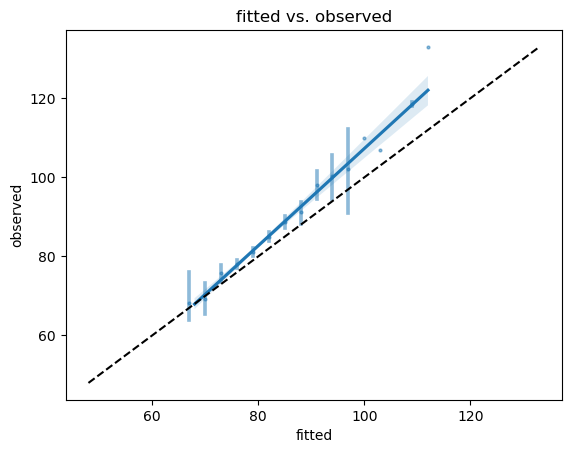

In [63]:
with torch.no_grad():
    plot_fitted_observed_TS(model, val_dl, bce=bce, CNN=CNN, MMD=MMD, DTF = False)

In [225]:
#load_model(save_name, model)
model_dir = 'C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\ML_algorithms\\saved_models\\'
model_path = os.path.join(model_dir, save_name + ".pt")
checkpoint = torch.load(model_path, weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])

RuntimeError: Error(s) in loading state_dict for Causal_CNN_Classifier_KG:
	size mismatch for u0: copying a param with shape torch.Size([]) from checkpoint, the shape in current model is torch.Size([1]).
	size mismatch for u1: copying a param with shape torch.Size([]) from checkpoint, the shape in current model is torch.Size([0]).
	size mismatch for u2: copying a param with shape torch.Size([]) from checkpoint, the shape in current model is torch.Size([0]).
	size mismatch for u3: copying a param with shape torch.Size([]) from checkpoint, the shape in current model is torch.Size([0]).

In [5]:
def kfold_df_from_array(array):
    df = pd.DataFrame({'arid lowlands': array[0, :],
                       'arid highlands': array[2, :],
                       'humid lowlands': array[3, :],
                       'humid highlands': array[4, :],
                       'cities': array[1, :]})
    return df

In [147]:
df_early_first.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\early_vars_split_scores.csv')